Note: The model has been trained on Colab (with cuda). Some of the images have been generated locally by loading the weights. This demanded some changes in
the code and might therefore cause the code not to run properly.

In [11]:

import os
SAVE_DIR = "data"
#os.makedirs(SAVE_DIR, exist_ok=True)
import matplotlib.pyplot as plt

In [12]:
import torchvision
# For image transforms
from torchvision import transforms
# For DATA SET
import torchvision.datasets as datasets
# For Pytorch methods
import torch
import torch.nn as nn
# For Optimizer
import torch.optim as optim
# FOR DATA LOADER
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from denoising_diffusion_pytorch import Unet, GaussianDiffusion

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
# if device.type != "cuda":
#     raise ValueError(f"Does not work with device {device.type}!")
print(f"Device = {device}")
# Hyperparameters
LEARNING_RATE = 4e-4
BATCH_SIZE = 128  # Batch size
N_EPOCHS = 100
IMAGE_SIZE = 28
TIME_STEPS = 1000
SAMPLING_TIMESTEPS = 250

# we define a tranform that converts the image to tensor
# also: This transform directly normalizes data to [0,1]
myTransforms = transforms.Compose([transforms.ToTensor()])

# the MNIST dataset is available through torchvision.datasets
print("loading MNIST digits dataset")
#dataset = datasets.MNIST(root="dataset/", transform=myTransforms, download=True)
# let's create a dataloader to load the data in batches
#loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

train_dataset = datasets.MNIST(root='dataset/', train=True, download=True, transform=myTransforms)
val_dataset = datasets.MNIST(root='dataset/', train=False, download=True, transform=myTransforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


DIM = 32
DIM_MULTS = (1, 2, 5)
model = Unet(
    dim = DIM,
    dim_mults = DIM_MULTS,
    flash_attn = False,
    channels = 1
)
model=model.to(device)

diffusion = GaussianDiffusion(
    model,
    image_size = IMAGE_SIZE,
    timesteps = TIME_STEPS,           # number of steps
    sampling_timesteps = SAMPLING_TIMESTEPS    # number of sampling timesteps (using ddim for faster inference [see ddim paper])
)
diffusion=diffusion.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

Device = cpu
loading MNIST digits dataset


In [18]:
scaler = torch.amp.GradScaler('cuda') # suggested by ChatGPT to enhance computation time, only works for cuda

epochs = tqdm(range(N_EPOCHS))  # this makes a nice progress bar
train_loss_hist=[]
val_loss_hist=[]
for epoch in epochs: # loop over epochs

    model.train()
    train_loss = 0  # reset train loss

    for training_images, _ in train_loader: # labels not used -> _
        # sample a batch of data
        optimizer.zero_grad() # ´clear old gradients
        training_images=training_images.to(device)
        #-----------------
        # forward pass

        if device.type == "cuda":
            with torch.amp.autocast("cuda"):
                loss = diffusion(training_images)

                scaler.scale(loss).backward()# compute gradients
                scaler.step(optimizer)
                scaler.update()# update parameters
        else:
            loss = diffusion(training_images)
            loss.backward()# compute gradients
            optimizer.step()# update parameters
        with torch.amp.autocast('cuda'):
            loss = diffusion(training_images)

        train_loss += loss.item() # add loss to total loss for current epoch
        #-----------------

    train_loss=train_loss/len(train_loader)
    train_loss_hist.append(train_loss)

    # compute the loss on the validation set
    model.eval()
    val_loss = 0
    with torch.no_grad(): # no operation tracking for gradient computation -> only evaluation
      # Corrected unpacking: assign the enumerate index to a dummy variable '_'
      for validation_images, _ in val_loader:
        validation_images=validation_images.to(device)
        loss = diffusion(validation_images)
        val_loss += loss.item()

    val_loss /=len(val_loader)
    val_loss_hist.append(val_loss)
    epochs.set_description(f"Training loss = {train_loss:.5f}, Validation loss = {val_loss:.5f}") # print losses next to progress bar

    if (epoch + 1) % 5 == 0:
        sampled_images=diffusion.sample(batch_size = 24)
        torchvision.utils.save_image(
            sampled_images,
            f"{SAVE_DIR}/generated_digits_epoch_{epoch+1}.png",
            nrow=8,
            normalize=True
        )
    if (epoch + 1) % 10 == 0:
        torch.save(model.state_dict(),f"{SAVE_DIR}/MNIST_diffusion_epoch_{epoch+1}.pth")


  0%|          | 0/100 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

...

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

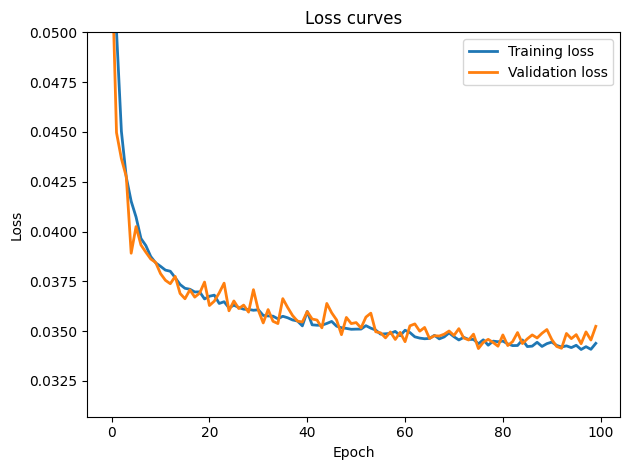

In [31]:
plt.plot(train_loss_hist,lw=2, alpha=1, label="Training loss")
plt.plot(val_loss_hist,lw=2,alpha=1,label="Validation loss")
plt.title("Loss curves")
plt.legend()
#plt.yscale("log")
plt.ylim(top=0.05)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/fullLossCurve.png")
plt.show()

Load saved weights locally

In [13]:
# Load weights
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
for i in range(10,101,10):
    model.load_state_dict(
    torch.load(f"{SAVE_DIR}/MNIST_diffusion_epoch_{i}.pth",map_location=device))
    model.eval()

    sampled_images=diffusion.sample(batch_size = 24)
    torchvision.utils.save_image(
        sampled_images,
        f"{SAVE_DIR}/new_generated_digits_epoch_{i}.png",
        nrow=8,
        normalize=True
    )

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

In [16]:
model.load_state_dict(
    torch.load(f"{SAVE_DIR}/MNIST_diffusion_epoch_100.pth",map_location=device))
model.eval()

sampled_images=diffusion.sample(batch_size = 32)
torchvision.utils.save_image(
    sampled_images,
    f"{SAVE_DIR}/new_generated_digits_epoch_100.png",
    nrow=8,
    normalize=True
)

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

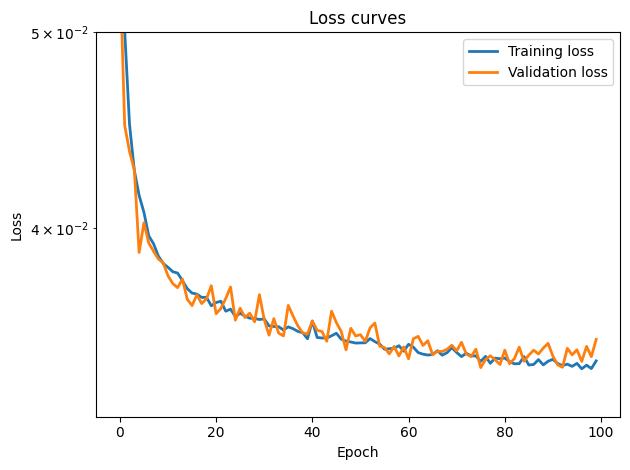

In [32]:
plt.plot(train_loss_hist,lw=2, alpha=1, label="Training loss")
plt.plot(val_loss_hist,lw=2,alpha=1,label="Validation loss")
plt.title("Loss curves")
plt.legend()
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylim(top=5e-2)
plt.ylabel("Loss")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/fullLossCurve2.png")
plt.show()

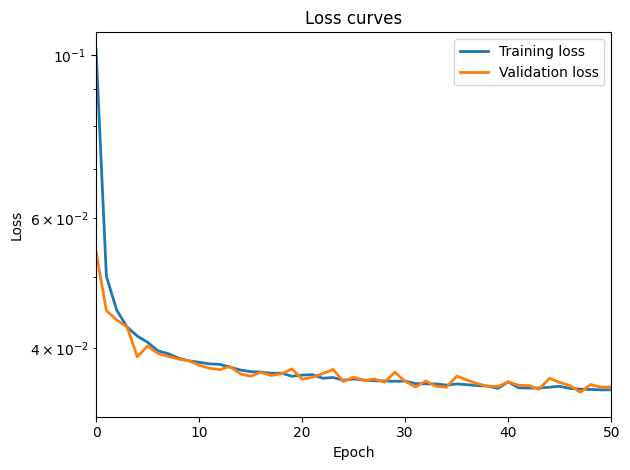

In [33]:
plt.plot(train_loss_hist,lw=2, alpha=1, label="Training loss")
plt.plot(val_loss_hist,lw=2,alpha=1,label="Validation loss")
plt.title("Loss curves")
plt.legend()
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xlim(0,50)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/fullLossCurve3.png")
plt.show()